In [17]:
import tqdm
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

In [18]:
import torch
import numpy as np
import os
import sys
import json
import glob
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score

sys.path.insert(0, '../Lensing_DomainAdaptation')
from models import Encoder, Classifier
from dataset import Len, prep_data
from utils import Pretraining_HPAMS, set_seed
from algorithms.pretraining import PreTraining_Train, PreTraining_Test

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_seed(42)
print(f"Device: {device}")
print("All imports OK")

Device: cpu
All imports OK


In [19]:
from sklearn.model_selection import train_test_split
import numpy as np

BASE_DIR = '../lens-finding-test'
TRAIN_LENS = f'{BASE_DIR}/train_lenses'
TRAIN_NONLENS = f'{BASE_DIR}/train_nonlenses'

cls_lens = [TRAIN_LENS + '/' + f for f in os.listdir(TRAIN_LENS) if f.endswith('.npy')]
cls_nonlens = [TRAIN_NONLENS + '/' + f for f in os.listdir(TRAIN_NONLENS) if f.endswith('.npy')]

# 90:10 split
lens_train, lens_val = train_test_split(cls_lens, test_size=0.10, random_state=42)
nonlens_train, nonlens_val = train_test_split(cls_nonlens, test_size=0.10, random_state=42)

def make_labeled(paths, label):
    return np.array([[p, str(label)] for p in paths])

X_train = np.concatenate([make_labeled(nonlens_train, 0), make_labeled(lens_train, 1)])
X_test = np.concatenate([make_labeled(nonlens_val, 0), make_labeled(lens_val, 1)])

print(f"Train lenses: {len(cls_lens)}, Train non-lenses: {len(cls_nonlens)}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train lenses: 1730, Train non-lenses: 28675
Train: (27364, 2), Test: (3041, 2)


In [20]:
# Define custom dataset wrapper to handle image shape corrections
# The original .npy files have shape (3, 64, 64), but the model expects (1, 64, 64)
# This wrapper converts multi-channel to single-channel via averaging

from torch.utils.data import Dataset

class LensDataset(Dataset):
    """
    Custom dataset wrapper that handles image preprocessing for lens finding.
    - Loads images from .npy files
    - Converts multi-channel (3, 64, 64) to single-channel via channel averaging
    - Normalizes to [0, 1] range
    - Returns tensors in PyTorch format: [C, H, W]
    """
    def __init__(self, data_paths, augmentations=None):
        self.base_dataset = Len(data_paths, augmentations)
        self.augmentations = augmentations
        
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        # Load metadata
        path = self.base_dataset.data[idx][0]
        label = float(self.base_dataset.data[idx][1])
        
        # Load and preprocess image
        image = np.load(path)
        
        # Convert multi-channel to single-channel by averaging
        if image.ndim == 3:
            image = np.mean(image, axis=0)
        
        # Normalize pixel values to [0, 1]
        img_min = np.min(image)
        img_max = np.max(image)
        image = (image - img_min) / (img_max - img_min) if img_max > img_min else image
        
        # Add channel dimension if needed: (H, W) -> (H, W, C)
        if image.ndim == 2:
            image = np.expand_dims(image, axis=2)
        
        # Apply augmentations if provided
        if self.augmentations is not None:
            transformed = self.augmentations(image=image)
            image = transformed['image']
        
        # Convert to PyTorch tensor in channels-first format [C, H, W]
        image_tensor = torch.tensor(image, dtype=torch.float32)
        image_tensor = image_tensor.permute(2, 0, 1)  # [H, W, C] -> [C, H, W]
        
        return image_tensor, torch.tensor(label, dtype=torch.long)

# Dataset configuration
image_size = 64
train_aug = None  # No augmentations for baseline
val_aug = None

# Create dataset instances with shape correction
train_data = LensDataset(X_train, train_aug)
val_data = LensDataset(X_test, val_aug)
test_data = LensDataset(X_test, val_aug)

In [21]:
train_data = LensDataset(X_train)
val_data = LensDataset(X_test)

train_loader = DataLoader(
    train_data, 
    shuffle=True,
    num_workers=0, 
    batch_size=64,
    drop_last=True, 
    pin_memory=False
)

val_loader = DataLoader(
    val_data, 
    shuffle=False,
    num_workers=0, 
    batch_size=128,
    drop_last=False, 
    pin_memory=False
)

# For 90:10 split, test = val
test_loader = DataLoader(
    val_data, 
    shuffle=False,
    num_workers=0, 
    batch_size=100,
    drop_last=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 427
Val batches: 24


In [22]:
# Verify dataset output shape
sample_image, sample_label = train_data[0]
print(f"Sample image shape: {sample_image.shape} (expected: [1, 64, 64])")
print(f"Sample label: {sample_label} (0=non-lens, 1=lens)")

Sample image shape: torch.Size([1, 64, 64]) (expected: [1, 64, 64])
Sample label: 0 (0=non-lens, 1=lens)


In [23]:
# Initialize encoder and classifier models
encoder = Encoder(model_name='tf_efficientnet_b2_ns', pretrained=False).to(device)
classifier = Classifier().to(device)

# Initialize hyperparameters for pretraining
hpms = Pretraining_HPAMS()
hpms.pretraining_epochs = 3
print("Model initialized")
print(f"Hyperparameters: {hpms.__dict__}")

Model initialized
Hyperparameters: {'pretraining_epochs': 3, 'pretraining_warmup_epochs': 3, 'pretraining_learning_rate': 0.0001, 'pretraining_weight_decay': 1e-05}


Starting training...


  0%|          | 0/427 [00:00<?, ?it/s]

Epoch 1/3: 100%|██████████| 427/427 [11:10<00:00,  1.57s/it, acc=0.969, auc=0.895, loss=0.128, stage=train] 


For epoch 1/3
average train_loss 0.3997365202955396
average train_auc nan
average train_acc 0.891173887587822


100%|██████████| 24/24 [00:20<00:00,  1.18it/s, acc=0, auc=nan, loss=2.3, stage=val]      


...

avarage val_loss 0.14276500455410376
avarage val_auc nan
avarage val_acc 0.9487010851693521


Epoch 3/3: 100%|██████████| 427/427 [10:54<00:00,  1.53s/it, acc=0.969, auc=0.986, loss=0.0983, stage=train]


For epoch 3/3
average train_loss 0.12257509284262355
average train_auc nan
average train_acc 0.9554303278688525


100%|██████████| 24/24 [00:17<00:00,  1.39it/s, acc=0.175, auc=nan, loss=2, stage=val]     


avarage val_loss 0.14389435655386265
avarage val_auc nan
avarage val_acc 0.9506741203551463


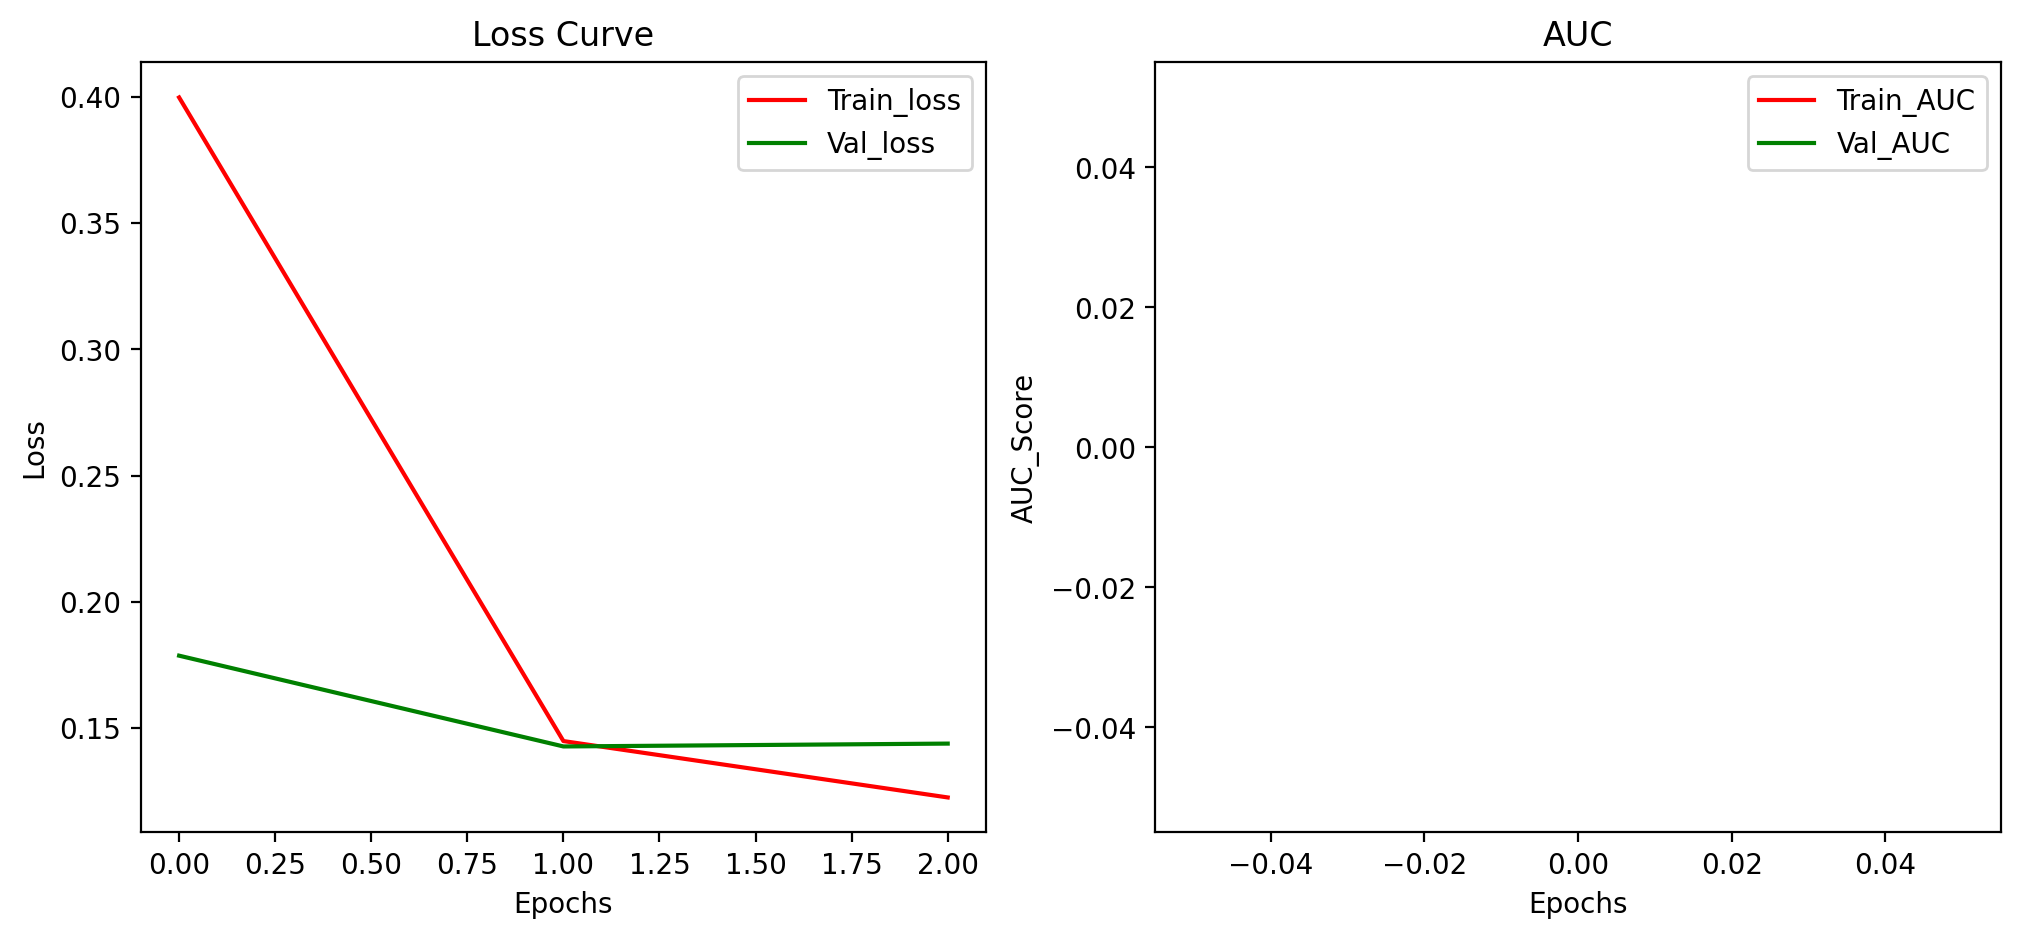

Training completed!


In [24]:
# Train the baseline model
OUTPUT_DIR = '../results/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Initialize and run supervised pretraining
trainer = PreTraining_Train(
    encoder, 
    classifier, 
    device,
    train_loader, 
    val_loader, 
    hpms,
    OUTPUT_DIR, 
    plot_metrics=True
)

print("Starting training...")
trainer.train()
print("Training completed!")

Loading: ../results/ Encoder_val_auc nan.pth


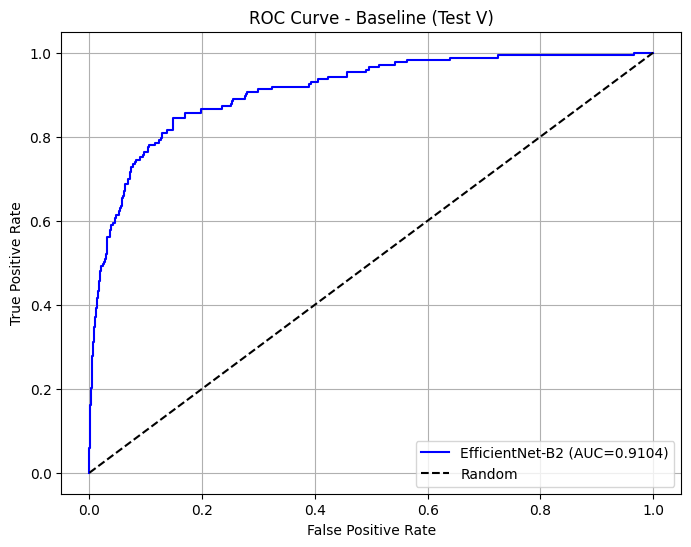

ROC curve saved to results/roc_curve_baseline.png

BASELINE EVALUATION RESULTS
AUCROC: 0.9104
PR-AUC: 0.5500


In [30]:
encoder_path = '../results/ Encoder_val_auc nan.pth'
classifier_path = '../results/ Classiifier_val_auc nan.pth'
print(f"Loading: {encoder_path}")

encoder.load_state_dict(torch.load(encoder_path, map_location=device))
classifier.load_state_dict(torch.load(classifier_path, map_location=device))
encoder.eval()
classifier.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        features = encoder(images)
        logits = classifier(features)
        predictions = torch.sigmoid(logits).cpu().numpy()
        all_predictions.extend(predictions.flatten())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

aucroc = roc_auc_score(all_labels, all_predictions)
prauc = average_precision_score(all_labels, all_predictions)


import matplotlib.pyplot as plt 
# ROC curve saved as PNG
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'EfficientNet-B2 (AUC={aucroc:.4f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline (Test V)')
plt.legend()
plt.grid()
plt.savefig('../results/roc_curve_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved to results/roc_curve_baseline.png")

metrics = {
    "model": "EfficientNet_B2_pretrain_baseline",
    "aucroc": round(aucroc, 4),
    "pr_auc": round(prauc, 4)
}
with open('../results/baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"\n{'='*40}")
print(f"BASELINE EVALUATION RESULTS")
print(f"{'='*40}")
print(f"AUCROC: {aucroc:.4f}")
print(f"PR-AUC: {prauc:.4f}")
print(f"{'='*40}")